In [1]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import torch

print("Torch:", torch.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.9.0+cu126


In [3]:
model = YOLO("/kaggle/input/models/rupankarmajumdar/yolo28n-30-epochs/tensorflow2/30-epochs/1/best (2).pt")

In [4]:
model.train(
    data="/kaggle/input/datasets/rupankarmajumdar/sentinelblue/data.yaml",
    epochs=50,
    imgsz=640,
    batch=192,
    device=[0,1],
    workers=12,
    project="training_resume",
    name="yolo11_resume"
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=192, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/datasets/rupankarmajumdar/sentinelblue/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/models/rupankarmajumdar/yolo28n-30-epochs/tensor

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:75: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.8s/it 32.4s
                   all       6874      17493       0.87      0.847      0.875      0.579

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      13.9G      1.625     0.8503   0.003872        365        640: 100% ━━━━━━━━━━━━ 204/204 2.9s/it 10:00
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.8s/it 33.0s
                   all       6874      17493      0.836      0.785      0.831      0.535

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      13.8G       1.72       0.92   0.004142        358        640: 100% ━━━━━━━━━━━━ 204/204 2.9s/it 9:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 2.3s/it 40.7s
                   all       6874      1749

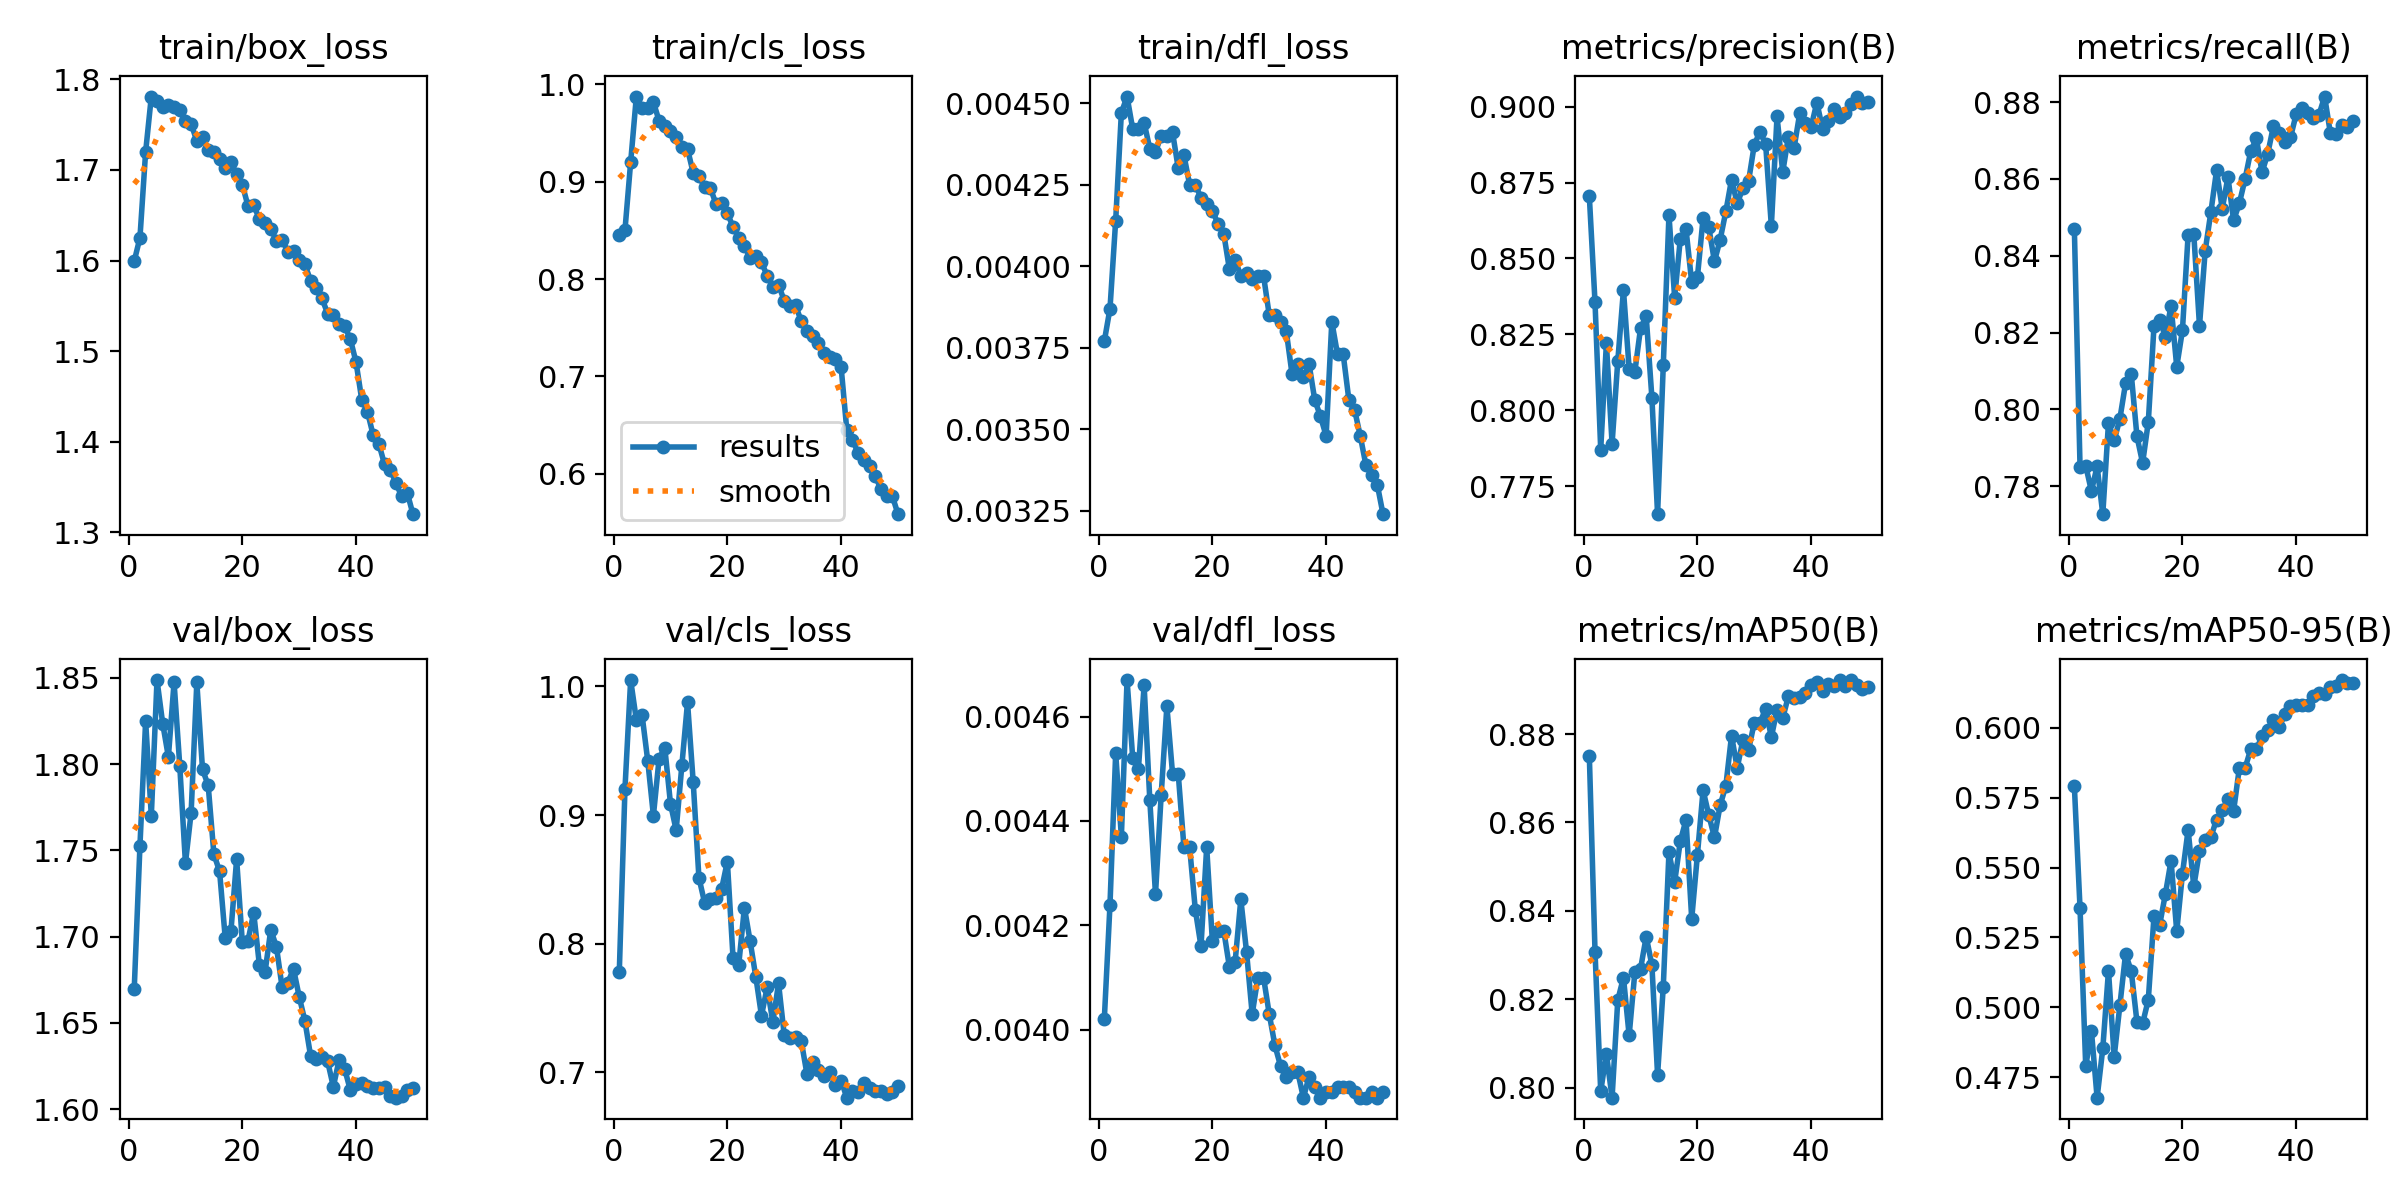

In [5]:
from IPython.display import Image, display
from pathlib import Path

Image("/kaggle/working/runs/detect/training_resume/yolo11_resume/results.png")

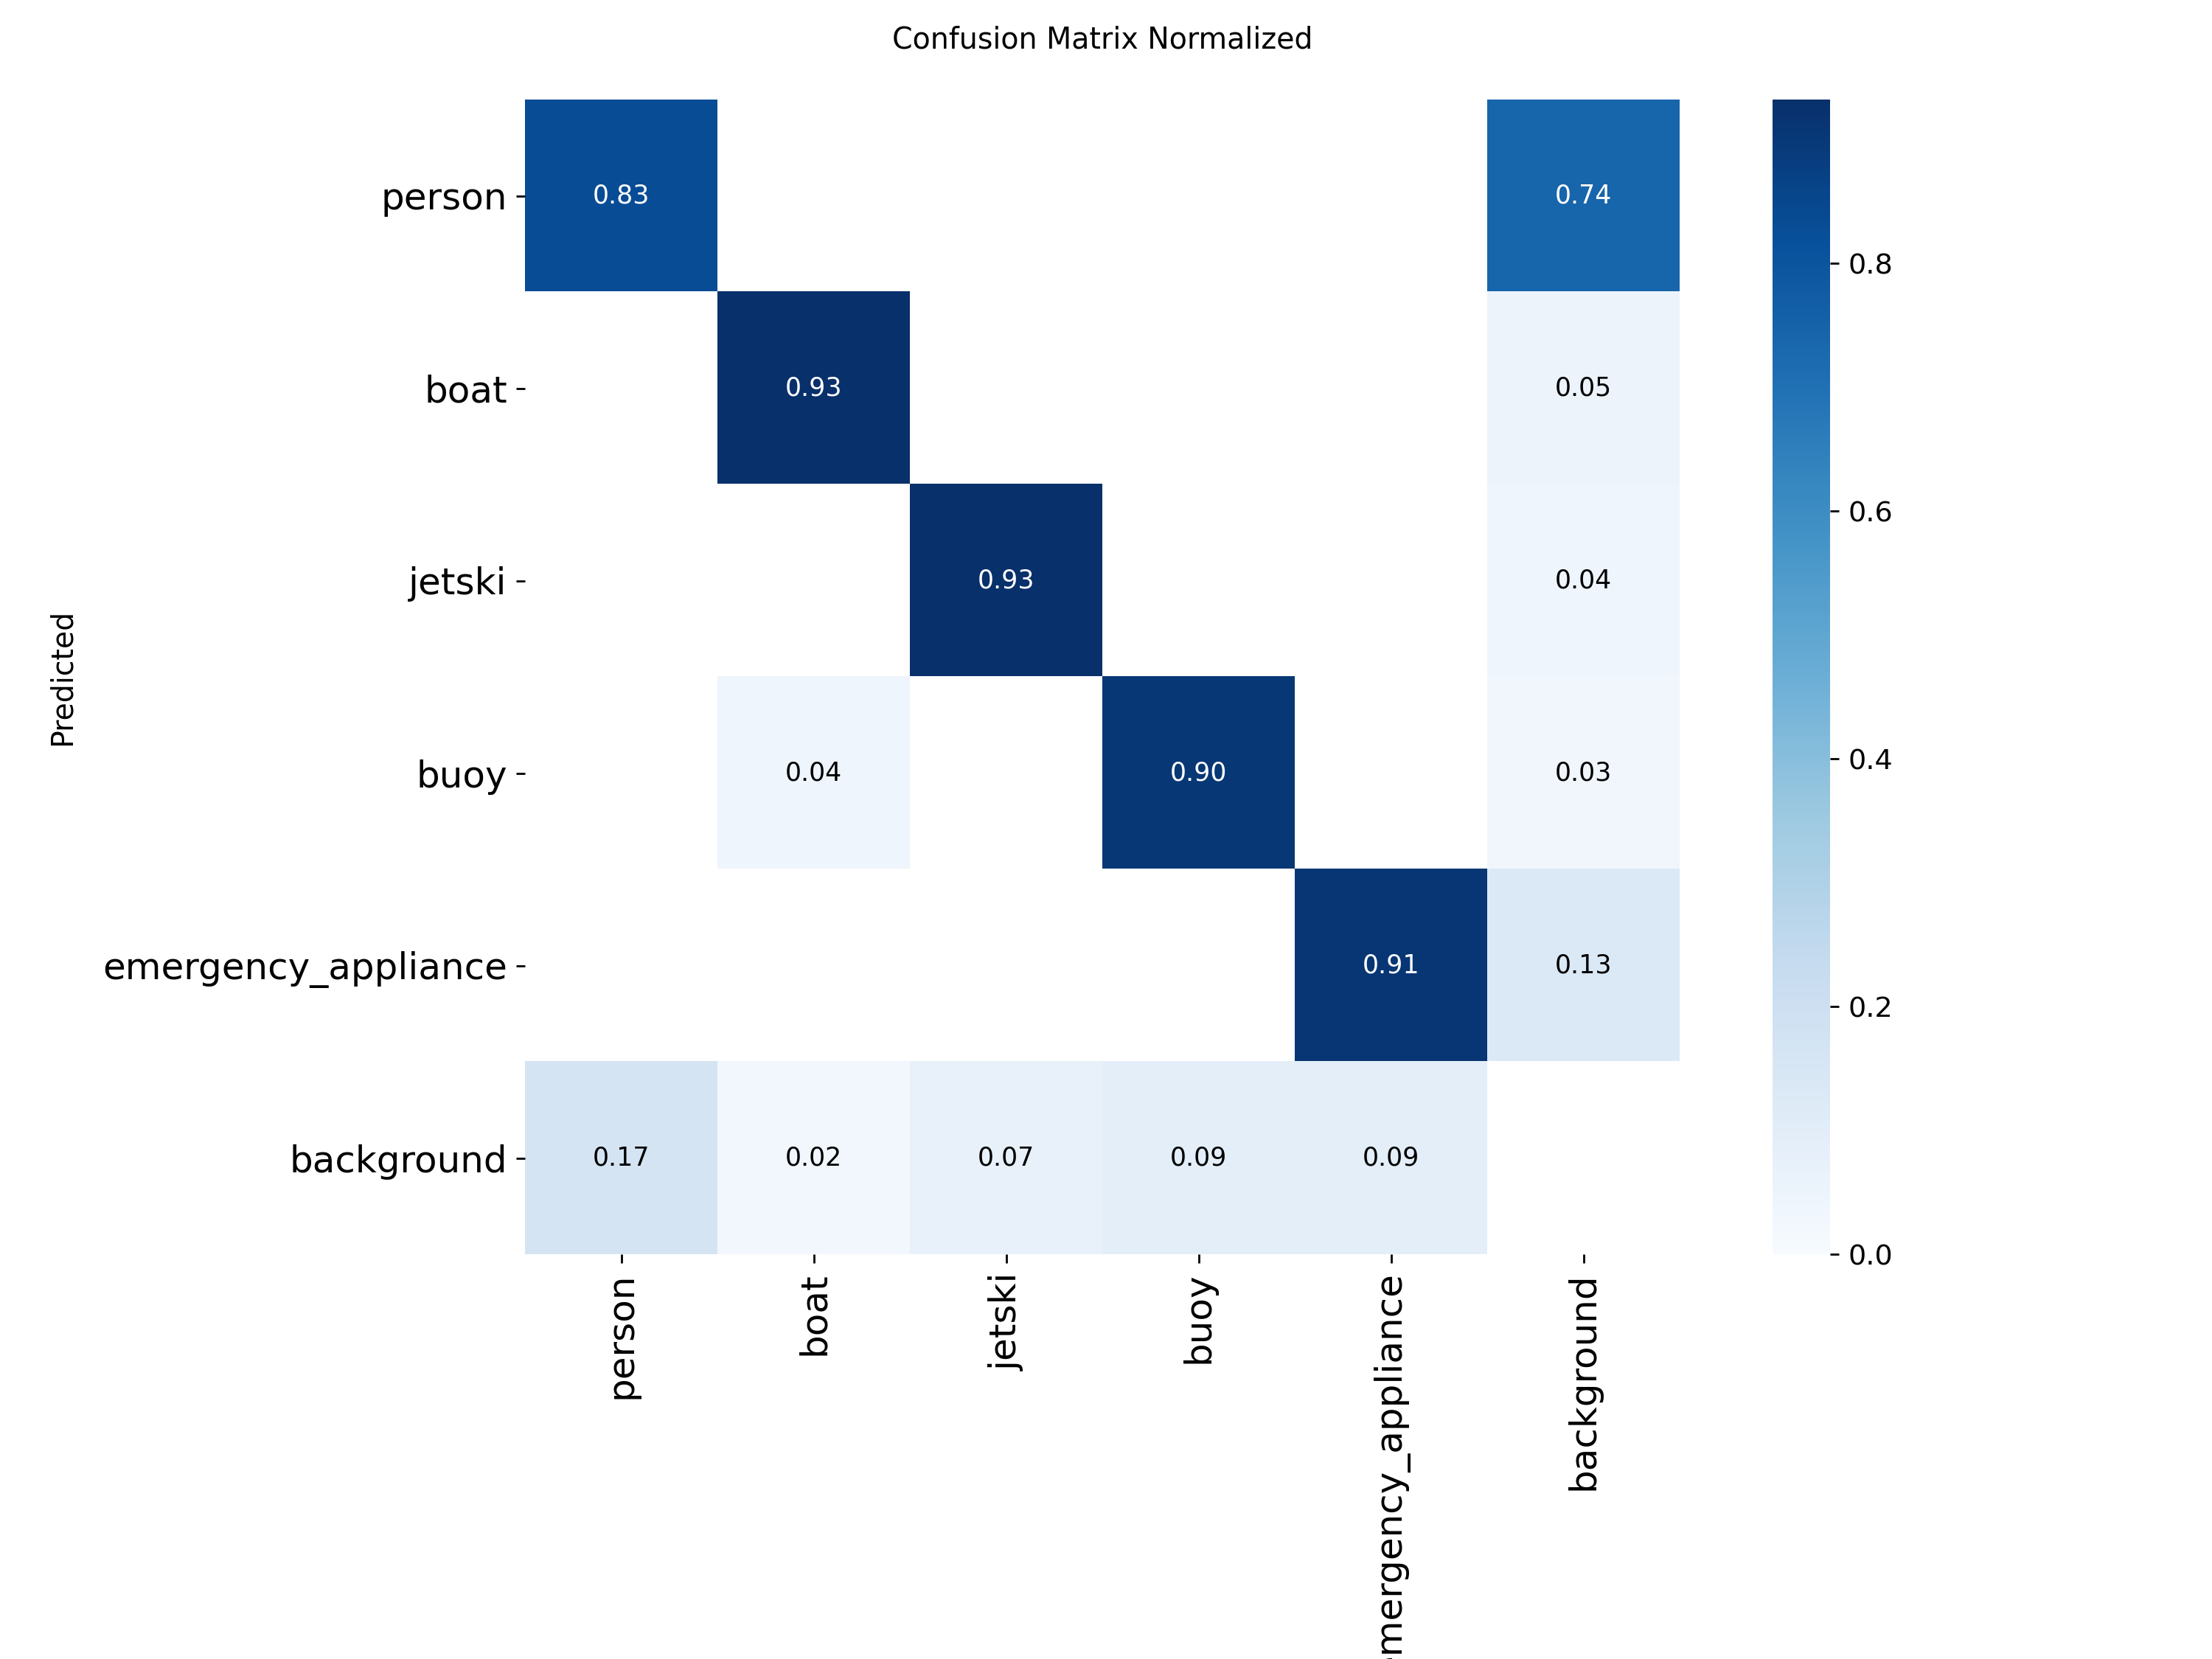

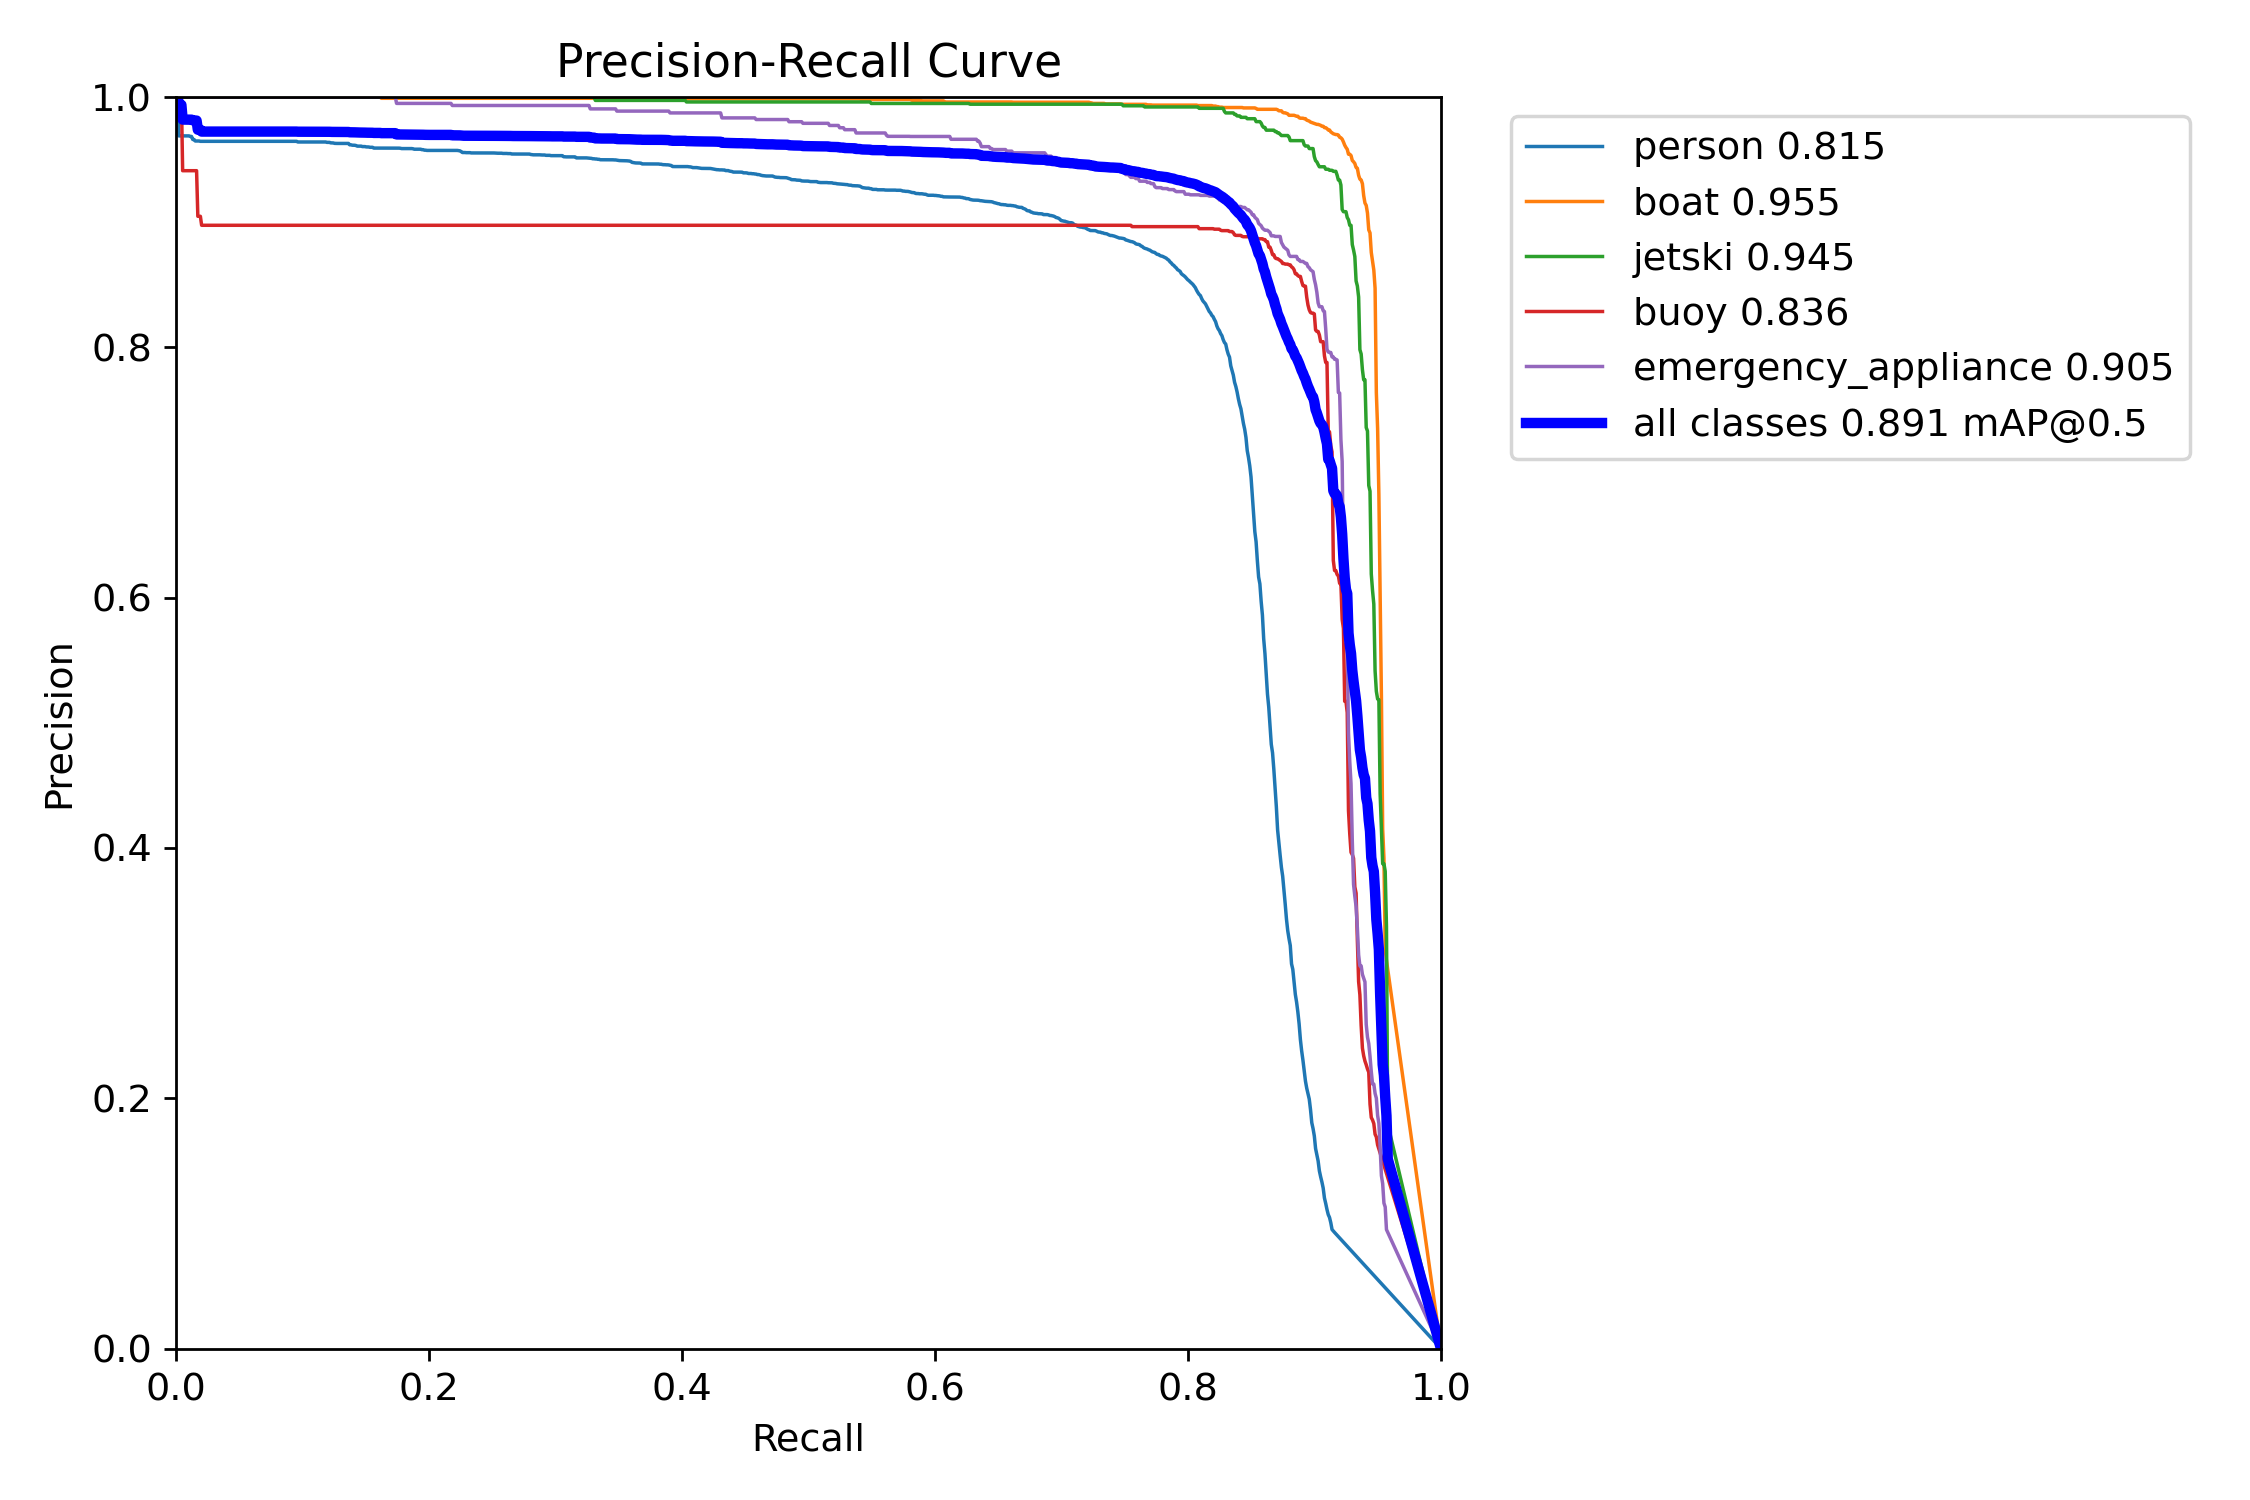

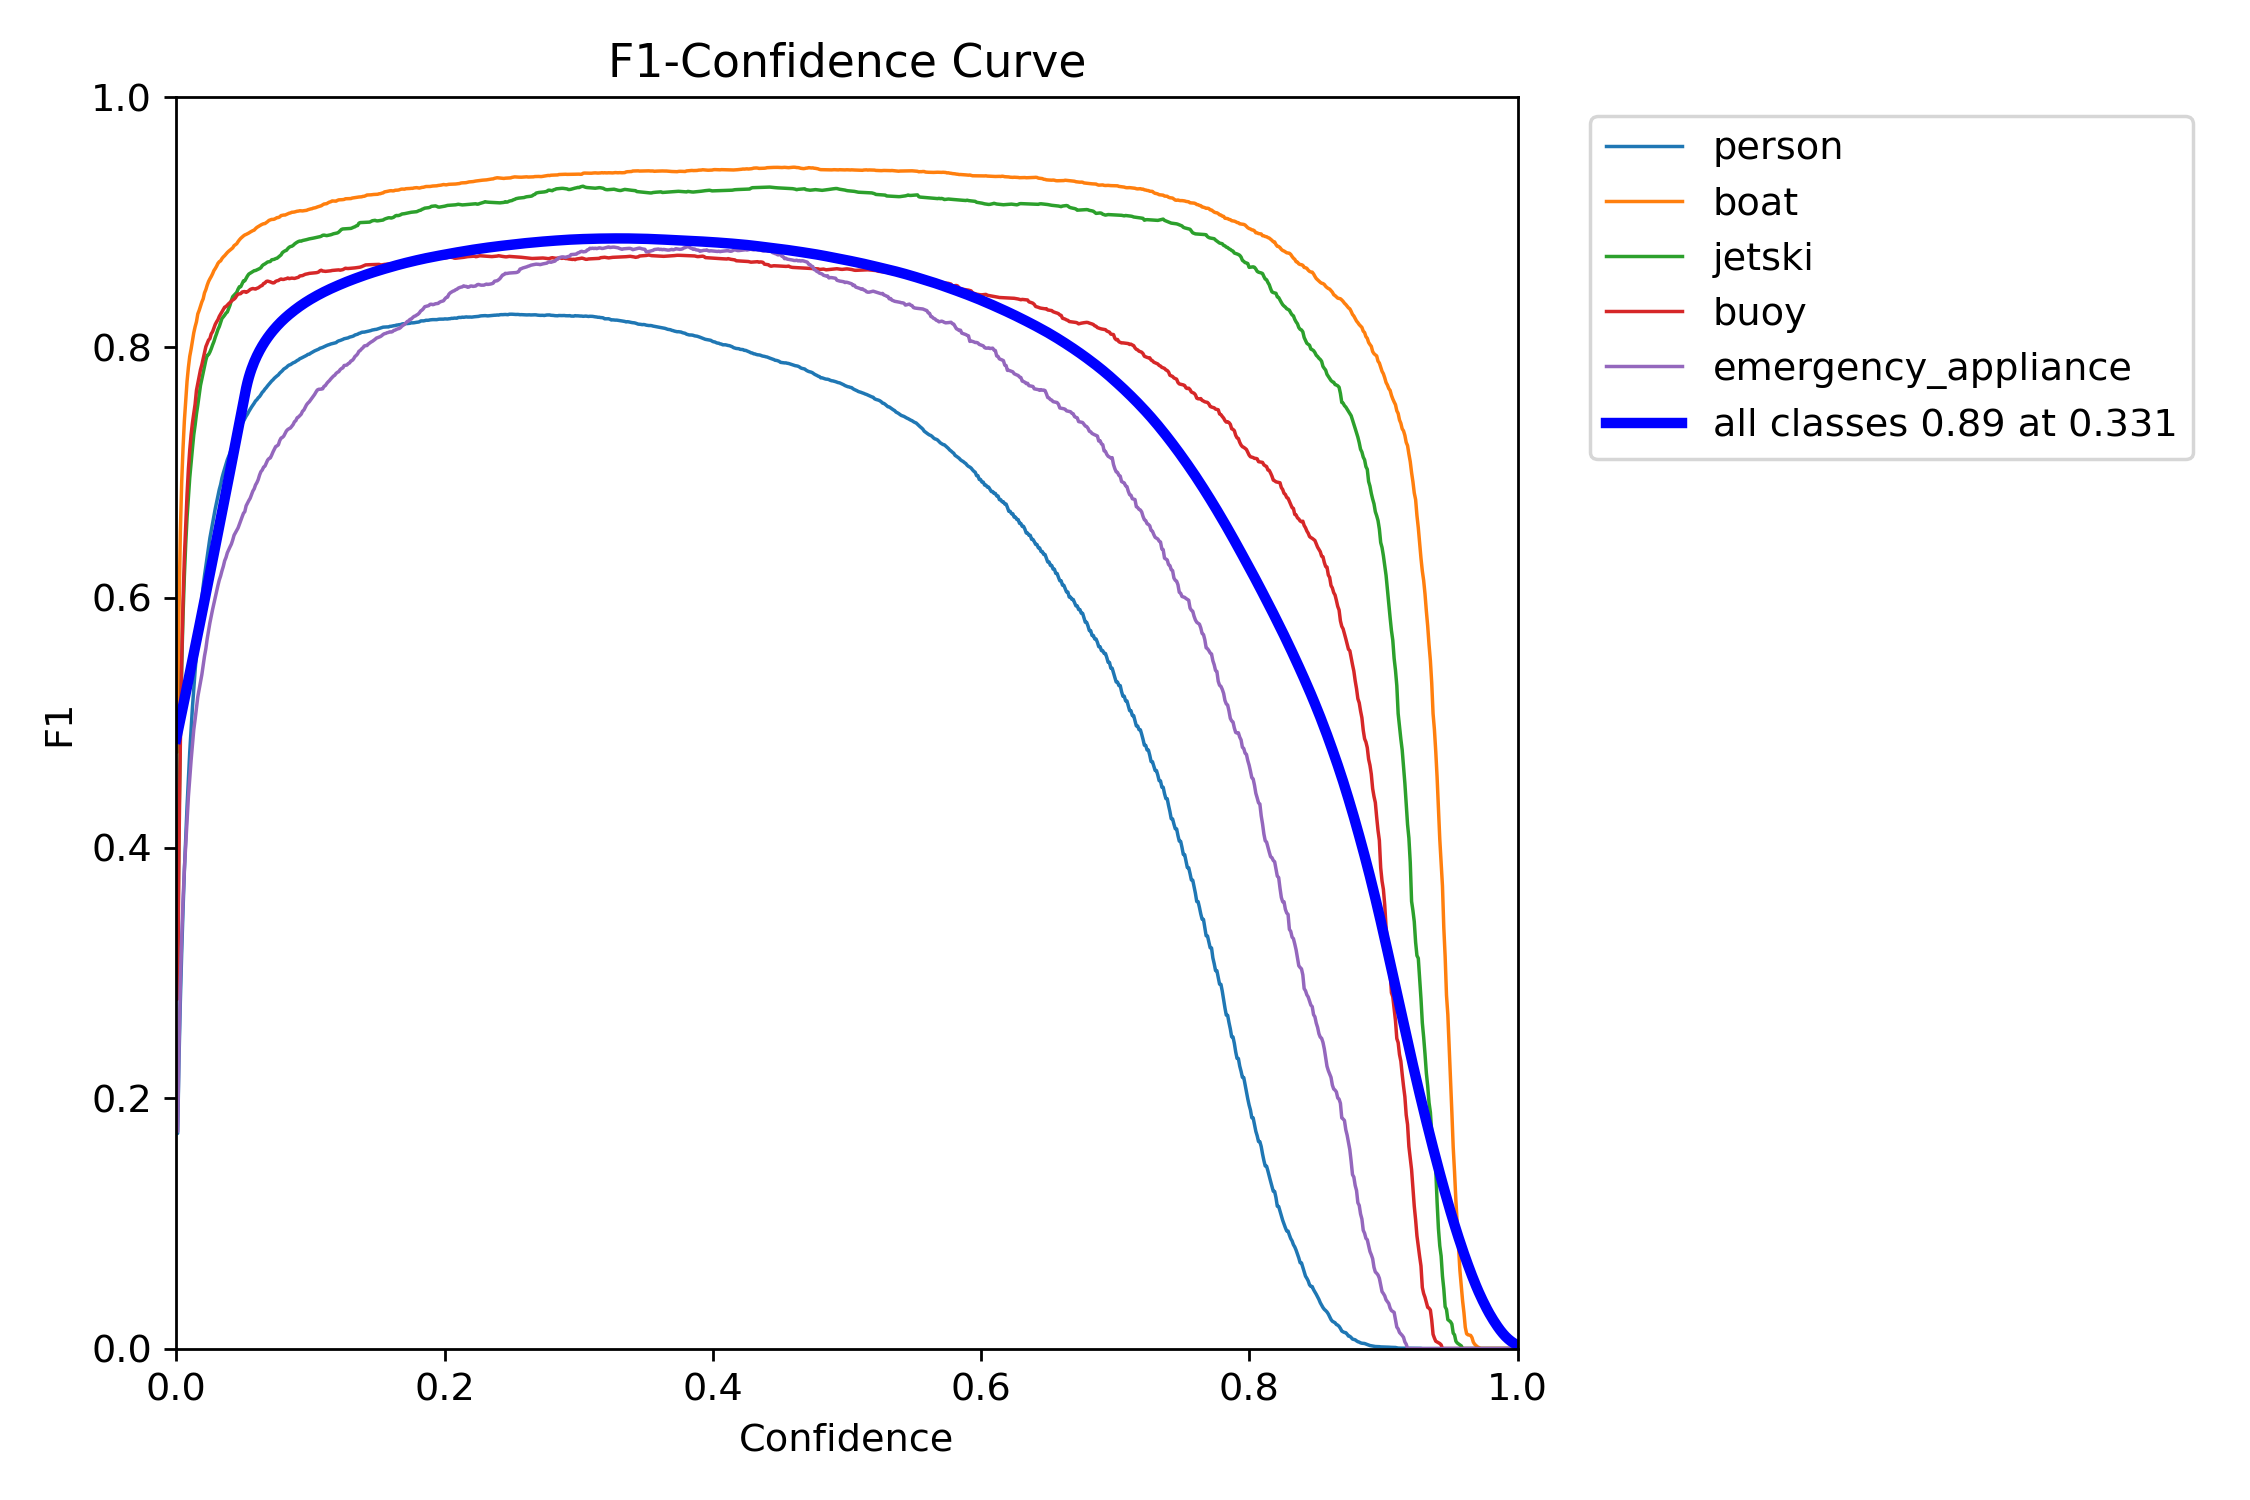

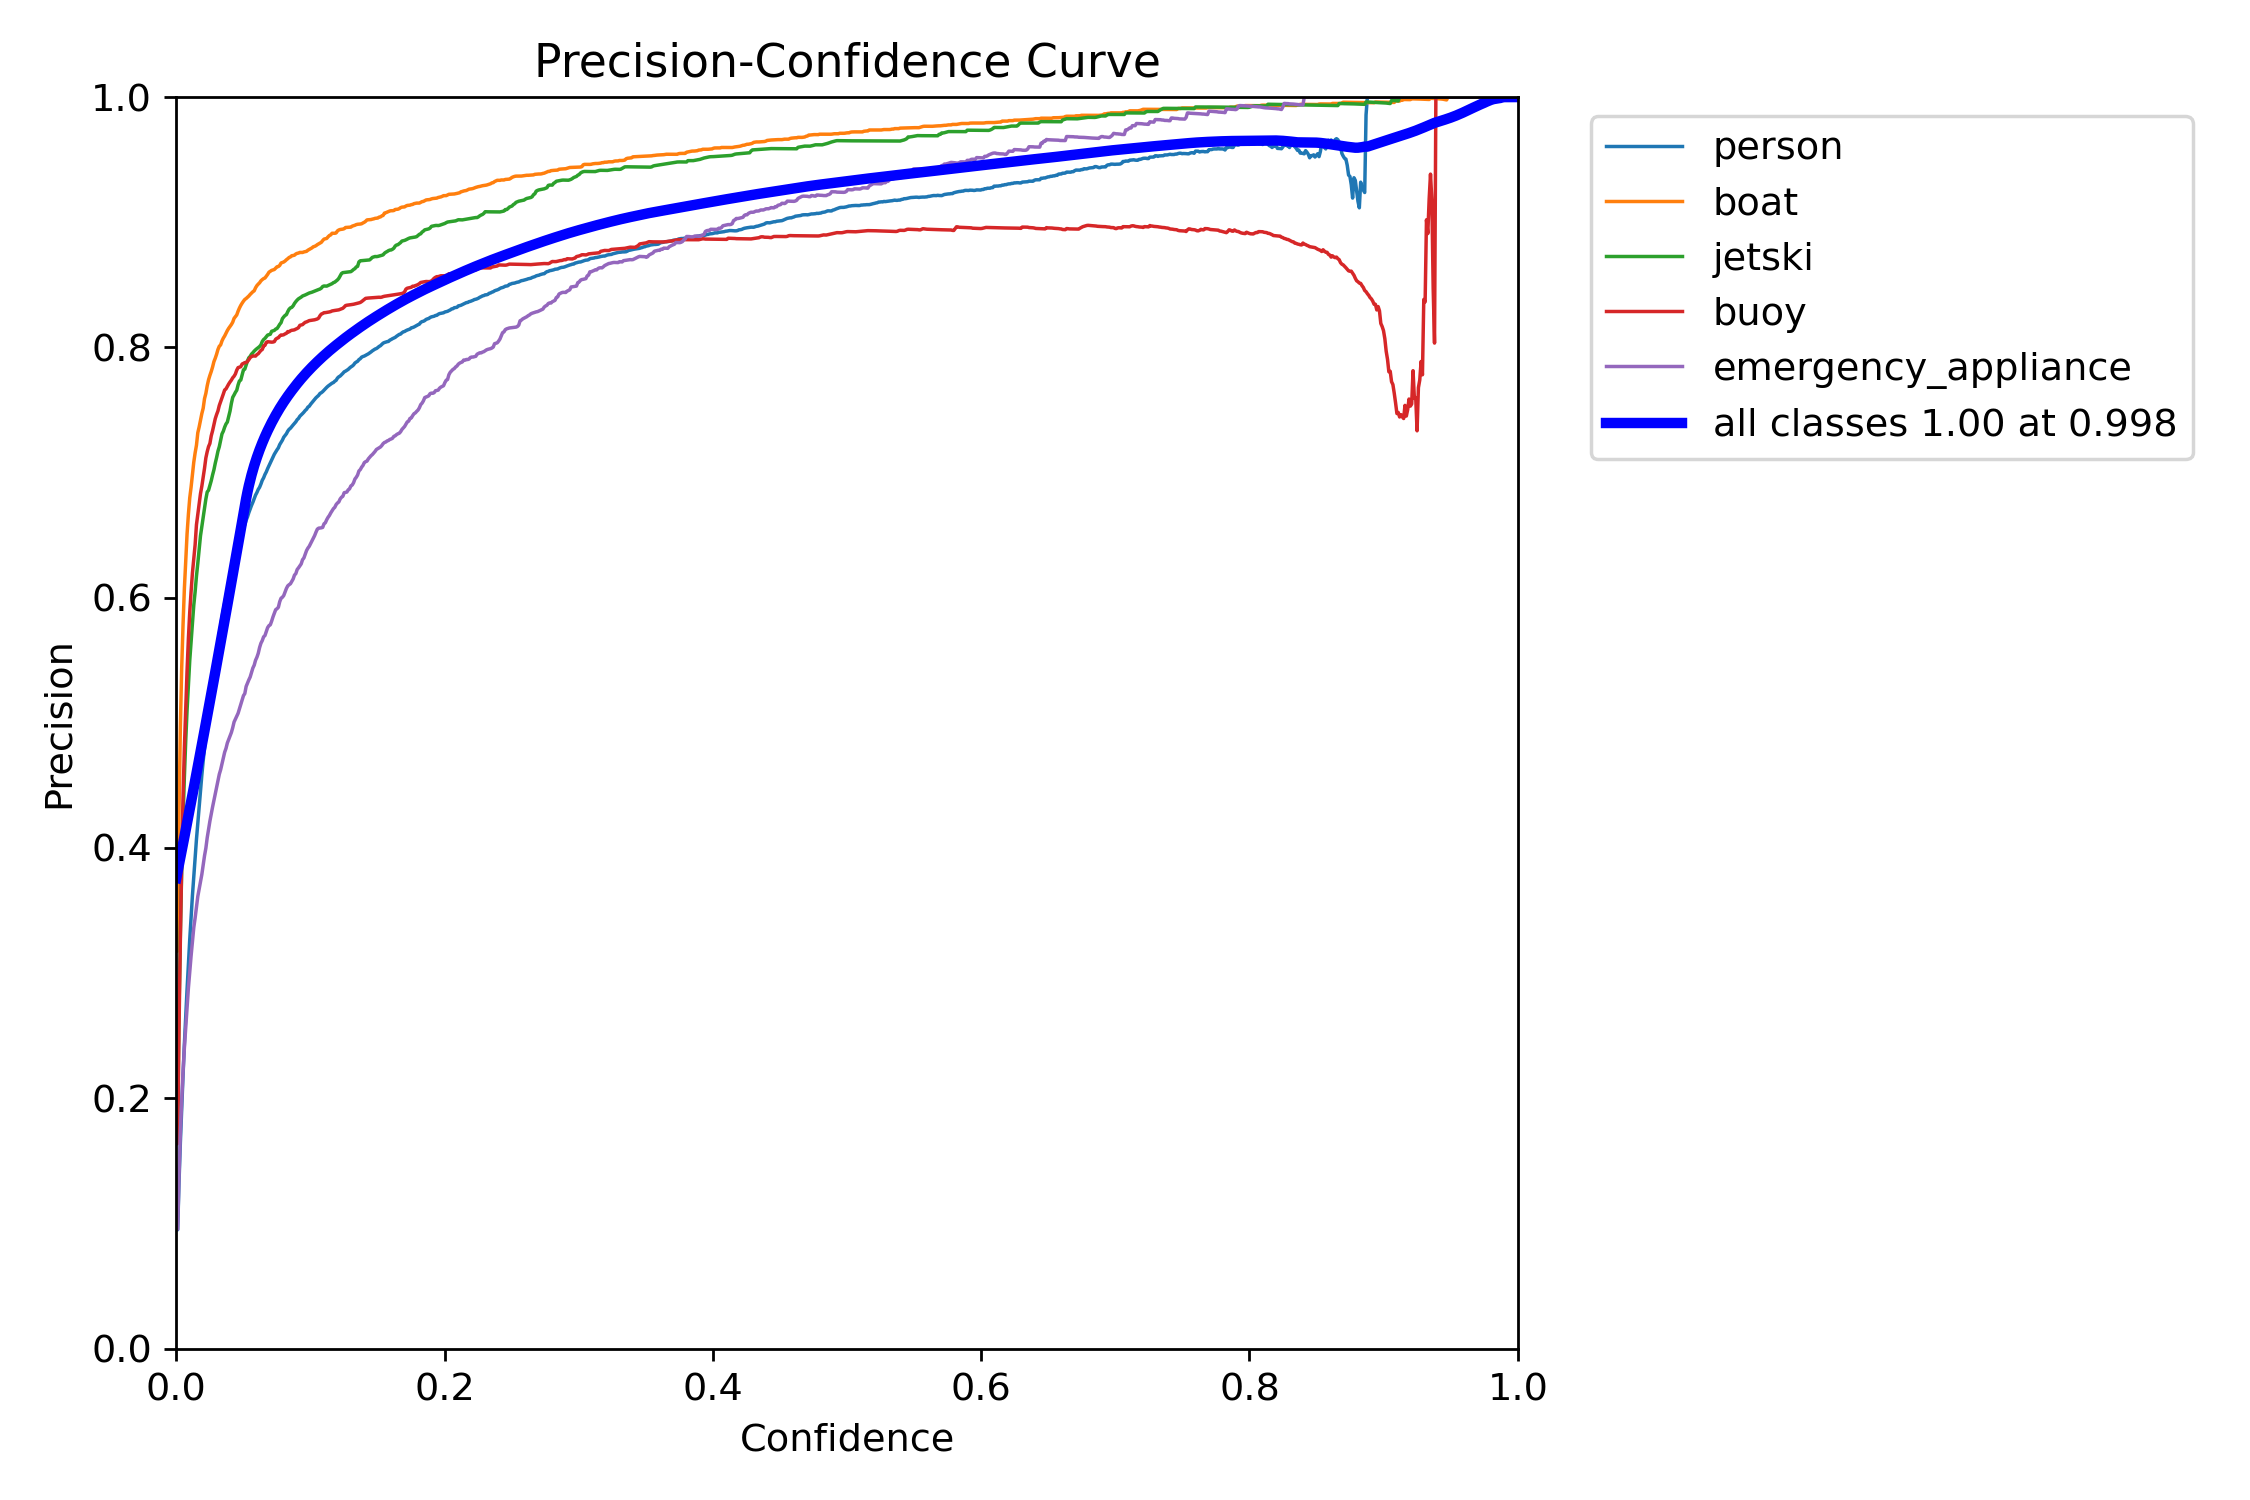

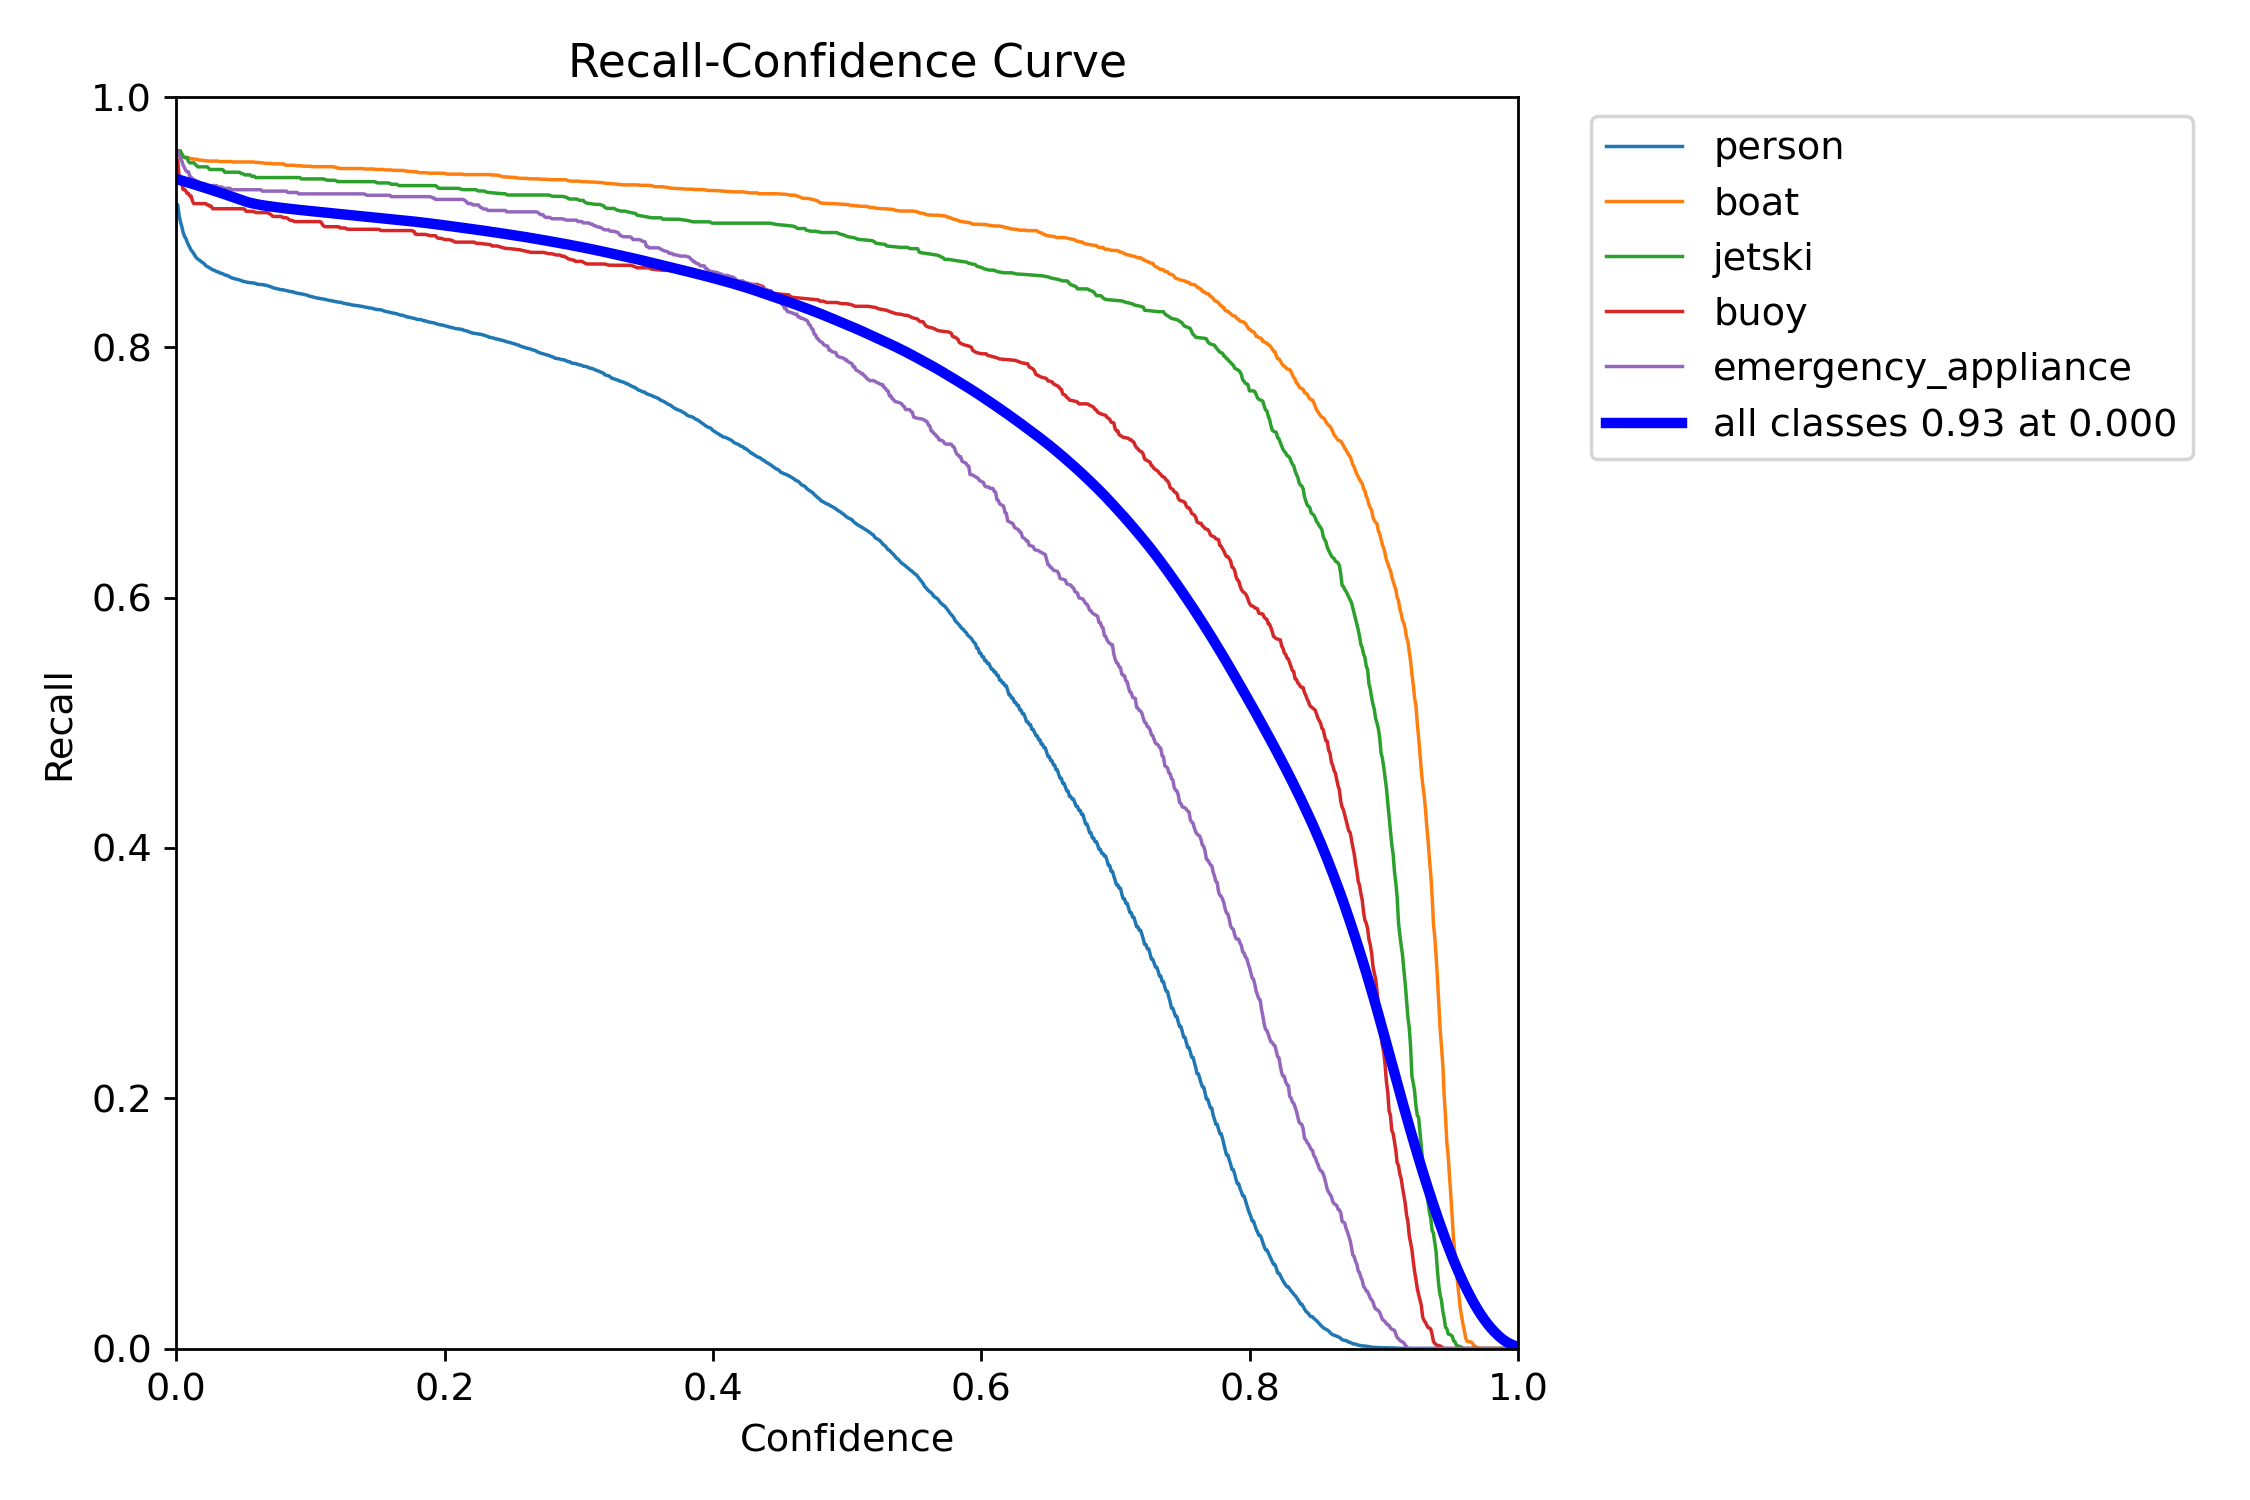

In [6]:
base_path = "/kaggle/working/runs/detect/training_resume/yolo11_resume"
display(Image(f"{base_path}/confusion_matrix_normalized.png"))
display(Image(f"{base_path}/BoxPR_curve.png"))
display(Image(f"{base_path}/BoxF1_curve.png"))
display(Image(f"{base_path}/BoxP_curve.png"))
display(Image(f"{base_path}/BoxR_curve.png"))